First, we import the essential libraries. `Pandas` is the backbone of data manipulation, while `Matplotlib` and `Seaborn` are used for visualization.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set a visual style for the plots
sns.set_theme(style="whitegrid")

print("✅ Libraries Imported Successfully")

✅ Libraries Imported Successfully


To make this tutorial standalone, we will generate a realistic e-commerce dataset containing sales data for an electronics store.

In [4]:
np.random.seed(42)

data_size = 500
categories = ['Electronics', 'Clothing', 'Home & Garden', 'Books']
products = {
    'Electronics': ['Smartphone', 'Laptop', 'Headphones', 'Monitor'],
    'Clothing': ['T-Shirt', 'Jeans', 'Sneakers', 'Jacket'],
    'Home & Garden': ['Chair', 'Desk', 'Lamp', 'Plant'],
    'Books': ['Novel', 'Textbook', 'Comic', 'Cookbook']
}

date_range = pd.date_range(start='2023-01-01', periods=data_size, freq='D')
category_list = np.random.choice(categories, data_size)
product_list = [np.random.choice(products[cat]) for cat in category_list]
price_list = np.random.randint(20, 1000, data_size)
quantity_list = np.random.randint(1, 5, data_size)

df = pd.DataFrame({
    'Date': date_range,
    'Category': category_list,
    'Product': product_list,
    'Price': price_list,
    'Quantity': quantity_list,
    'Rating': np.random.uniform(1.0, 5.0, data_size) # Ratings between 1 and 5
})

df.loc[10:20, 'Price'] = np.nan
df.loc[50:55, 'Category'] = np.nan

print("✅ Synthetic Dataset Created")
df.head(10)

✅ Synthetic Dataset Created


,Date,Category,Product,Price,Quantity,Rating
0,2023-01-01,Home & Garden,Lamp,521.0,2,1.884838
1,2023-01-02,Books,Novel,978.0,1,4.950672
2,2023-01-03,Electronics,Smartphone,164.0,1,4.776237
3,2023-01-04,Home & Garden,Plant,220.0,1,1.157707
4,2023-01-05,Home & Garden,Lamp,948.0,1,3.822301
5,2023-01-06,Books,Novel,743.0,3,4.700993
6,2023-01-07,Electronics,Monitor,480.0,3,1.722301
7,2023-01-08,Electronics,Headphones,751.0,1,3.271781
8,2023-01-09,Home & Garden,Plant,771.0,2,4.661953
9,2023-01-10,Clothing,Jeans,944.0,4,1.135784


Before analyzing, we must understand the shape and health of our data. We check for data types and missing values.

In [7]:
# DATA INSPECTION

# print("--- Data Info ---")
# df.info()

# print("\n--- Summary Statistics ---")
# display(df.describe())

print("\n--- Missing Values ---")
print(df.isnull().sum())


--- Missing Values ---
Date         0
Category     6
Product      0
Price       11
Quantity     0
Rating       0
dtype: int64


Data is rarely perfect. Here we handle the missing values we introduced earlier.

In [8]:
# DATA CLEANING

# 1. Fill missing 'Category' with 'Unknown'
df['Category'] = df['Category'].fillna('Unknown')

# 2. Fill missing 'Price' with the median price (better than mean for skewed data)
median_price = df['Price'].median()
df['Price'] = df['Price'].fillna(median_price)

# 3. Check if clean
print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
Date        0
Category    0
Product     0
Price       0
Quantity    0
Rating      0
dtype: int64


We often need to create new data based on existing columns. Here, we calculate Total Revenue.

In [9]:
# FEATURE ENGINEERING

df['Revenue'] = df['Price'] * df['Quantity']

df['Month'] = df['Date'].dt.month_name()

df.head()

,Date,Category,Product,Price,Quantity,Rating,Revenue,Month
0,2023-01-01,Home & Garden,Lamp,521.0,2,1.884838,1042.0,January
1,2023-01-02,Books,Novel,978.0,1,4.950672,978.0,January
2,2023-01-03,Electronics,Smartphone,164.0,1,4.776237,164.0,January
3,2023-01-04,Home & Garden,Plant,220.0,1,1.157707,220.0,January
4,2023-01-05,Home & Garden,Lamp,948.0,1,3.822301,948.0,January


Let's answer business questions. Which category generates the most revenue?

In [13]:
# DATA ANALYSIS (AGGREGATION)

category_revenue = df.groupby('Category')['Revenue'].sum().sort_values(ascending=False)

print("--- Total Revenue by Category ---")
print(category_revenue)

--- Total Revenue by Category ---
Category
Books            182615.0
Clothing         145544.0
Electronics      145263.0
Home & Garden    130621.0
Unknown            8991.0
Name: Revenue, dtype: float64


Visualizing the Revenue by Category.

/tmp/ipython-input-4185415494.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_revenue.index, y=category_revenue.values, palette="viridis")


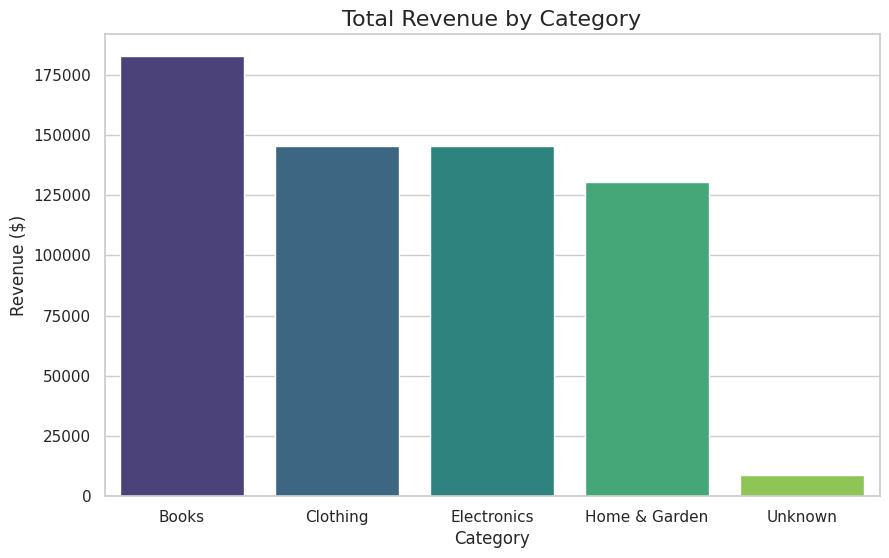

In [14]:
# VISUALIZATION

plt.figure(figsize=(10, 6))
sns.barplot(x=category_revenue.index, y=category_revenue.values, palette="viridis")

plt.title("Total Revenue by Category", fontsize=16)
plt.xlabel("Category")
plt.ylabel("Revenue ($)")
plt.show()

Analyzing the relationship between Price and Customer Rating. Do expensive items get better ratings?

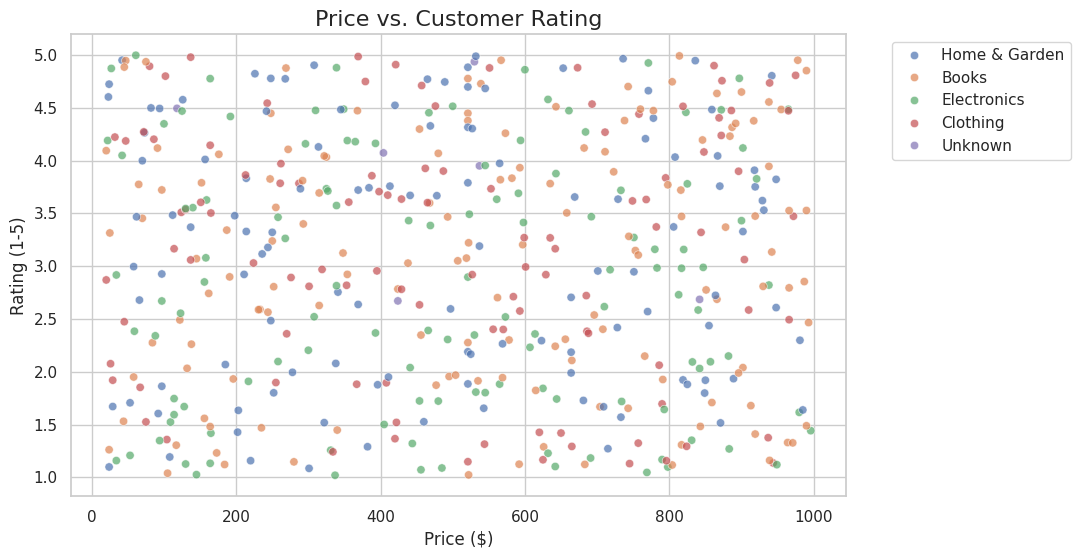

In [15]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Price', y='Rating', hue='Category', alpha=0.7)

plt.title("Price vs. Customer Rating", fontsize=16)
plt.xlabel("Price ($)")
plt.ylabel("Rating (1-5)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

How did sales perform over time?

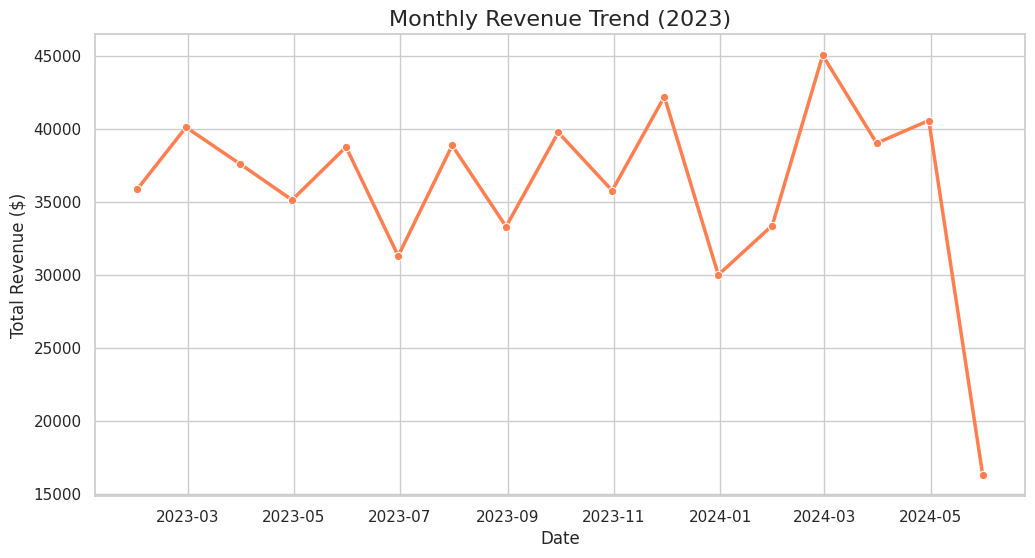

In [16]:
monthly_sales = df.set_index('Date').resample('ME')['Revenue'].sum()

plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly_sales, marker='o', color='coral', linewidth=2.5)

plt.title("Monthly Revenue Trend (2023)", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Total Revenue ($)")
plt.grid(True)
plt.show()